# AI Washing Index — Temporal Evolution by Disclosure Archetype

Plots how the AI washing index (hype vs. substance gap) evolves over time for each disclosure archetype from `clustering_archetypes.ipynb`.

**Index:**
- **Hype** = z(`share_gen_ai_mention`) + z(`share_promotional`)
- **Substance** = z(`avg_specificity`) + z(`share_substantive`) + z(`share_capex_mention`) + z(`share_rd_mention`)
- **AI Washing Index** = Hype − Substance  *(positive = more claims than evidence)*

**Requires:** run `clustering_archetypes.ipynb` first to produce `data/processed/clusters/firm_year_clusters.parquet`.

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
DATA = Path('../data')

## 0. Load & merge

In [35]:
clusters_path = DATA / 'processed/clusters/firm_year_clusters.parquet'
features_path = DATA / 'processed/features/firm_year_features.parquet'

assert clusters_path.exists(), "Run clustering_archetypes.ipynb first"

clusters = pd.read_parquet(clusters_path)
features = pd.read_parquet(features_path)

# New signal columns from updated pipeline (has_* → share_*, ratio_* → avg_ratio_*)
NEW_HYPE_COLS      = ['avg_ratio_vague_words', 'avg_ratio_forward_to_realized']
NEW_SUBSTANCE_COLS = ['share_ai_quantified_claim', 'share_named_deployment', 'share_dated_milestone']

HYPE_COLS      = ['share_promotional'] + [c for c in NEW_HYPE_COLS      if c in features.columns]
SUBSTANCE_COLS = ['avg_specificity', 'share_substantive'] + [c for c in NEW_SUBSTANCE_COLS if c in features.columns]

FEAT_COLS = ['ticker', 'year', 'ai_mentions_count'] + HYPE_COLS + SUBSTANCE_COLS

df = clusters[['ticker', 'year', 'cluster', 'cluster_name', 'industry_group',
               'post_sec_2024', 'post_deepseek']].merge(
    features[[c for c in FEAT_COLS if c in features.columns]], on=['ticker', 'year'], how='left'
)

df['post_sec_2024'] = df['post_sec_2024'].astype(int)
df['post_deepseek'] = df['post_deepseek'].astype(int)

print(f'Merged: {df.shape}')
print(f'Hype components:      {HYPE_COLS}')
print(f'Substance components: {SUBSTANCE_COLS}')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Clusters: {sorted(df["cluster"].unique())}')
df[HYPE_COLS + SUBSTANCE_COLS].describe().round(4)


Merged: (658, 16)
Hype components:      ['share_promotional', 'avg_ratio_vague_words', 'avg_ratio_forward_to_realized']
Substance components: ['avg_specificity', 'share_substantive', 'share_ai_quantified_claim', 'share_named_deployment', 'share_dated_milestone']
Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,share_promotional,avg_ratio_vague_words,avg_ratio_forward_to_realized,avg_specificity,share_substantive,share_ai_quantified_claim,share_named_deployment,share_dated_milestone
count,658.0000,658.0000,658.0000,658.0000,658.0000,658.0000,658.0000,658.0000
mean,0.1496,0.0050,0.4454,0.4811,0.3583,0.0156,0.0025,0.0720
std,0.2506,0.0061,0.1786,0.5110,0.3740,0.0808,0.0207,0.1836
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.3580,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0030,0.5000,0.4000,0.3333,0.0000,0.0000,0.0000
75%,0.2500,0.0078,0.5000,1.0000,0.6667,0.0000,0.0000,0.0000
max,1.0000,0.0423,1.0000,2.6667,1.0000,1.0000,0.3043,1.0000


## 1. Compute AI washing index

In [36]:
# Within-(industry_group × year) z-scoring: measures deviation from same-year peers,
# not from the full panel (which encodes the 2022-2024 hype wave as "washing").
def within_group_zscore(series, groups):
    return series.groupby(groups).transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1)
    )

group_key = [df['industry_group'], df['year']]

for col in HYPE_COLS + SUBSTANCE_COLS:
    df[f'z_{col}'] = within_group_zscore(df[col].fillna(0), group_key)

df['hype_score']      = df[[f'z_{c}' for c in HYPE_COLS]].mean(axis=1)
df['substance_score'] = df[[f'z_{c}' for c in SUBSTANCE_COLS]].mean(axis=1)
df['ai_washing_index'] = df['hype_score'] - df['substance_score']

# Bounded normalized form: AWI_norm ∈ (−1, 1)
eps = 1e-6
df['awi_norm'] = df['ai_washing_index'] / (
    df['hype_score'].abs() + df['substance_score'].abs() + eps
)

# Non-disclosers get 0
non_disclosers = df['ai_mentions_count'].fillna(0) == 0
df.loc[non_disclosers, ['hype_score', 'substance_score', 'ai_washing_index', 'awi_norm']] = 0.0

# Cluster label
df['label'] = df.apply(
    lambda r: r['cluster_name'] if str(r['cluster_name']) not in ('TBD', 'nan', '')
              else f"Cluster {r['cluster']}", axis=1
)

K = df['cluster'].nunique()
palette = dict(zip(sorted(df['label'].unique()), sns.color_palette('tab10', K)))

print('AI washing index summary by cluster:')
print(df.groupby('label')[['hype_score', 'substance_score', 'ai_washing_index', 'awi_norm']].mean().round(3).to_string())


AI washing index summary by cluster:
                                  hype_score  substance_score  ai_washing_index  awi_norm
label                                                                                    
Boilerplate Risk-Warners               0.032           -0.163             0.195     0.172
Governance & Compliance-Focused       -0.034            0.050            -0.084    -0.112
Non-AI Disclosers                      0.000            0.000             0.000     0.000
Operational Application Adopters       0.176            0.191            -0.015    -0.041
Promotional AI Claimants               0.099            0.088             0.011     0.016


## 2. AI washing index through time by cluster

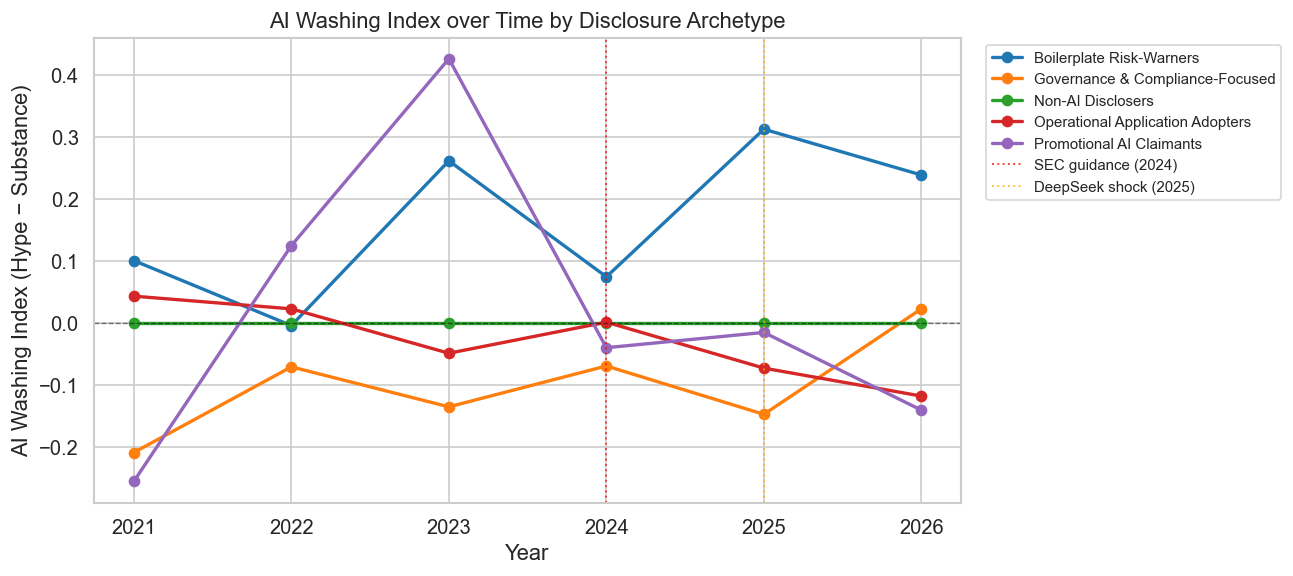

In [37]:
trend = df.groupby(['year', 'label'])[['ai_washing_index', 'hype_score', 'substance_score', 'awi_norm']].mean().reset_index()
years = sorted(df['year'].unique())

fig, ax = plt.subplots(figsize=(11, 5))

for label, grp in trend.groupby('label'):
    grp = grp.sort_values('year')
    ax.plot(grp['year'], grp['ai_washing_index'], marker='o', linewidth=2,
            label=label, color=palette[label])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(2024, color='red', linewidth=1.2, linestyle=':', alpha=0.7, label='SEC guidance (2024)')
ax.axvline(2025, color='orange', linewidth=1.2, linestyle=':', alpha=0.7, label='DeepSeek shock (2025)')

ax.set_xlabel('Year')
ax.set_ylabel('AI Washing Index (Hype − Substance)')
ax.set_title('AI Washing Index over Time by Disclosure Archetype')
ax.set_xticks(years)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/ai_washing_by_cluster_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Hype vs Substance decomposed — stacked by cluster

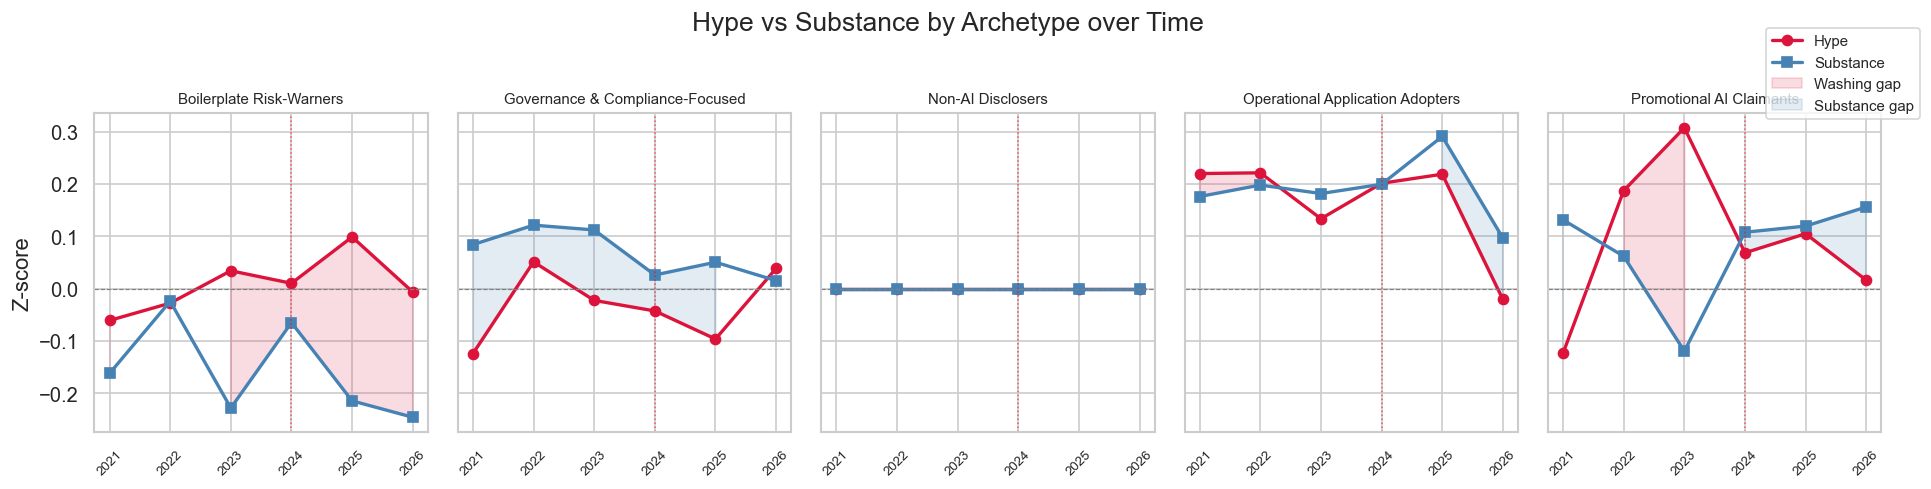

In [38]:
labels_sorted = sorted(df['label'].unique())
n = len(labels_sorted)
fig, axes = plt.subplots(1, n, figsize=(n * 3.2, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, label in zip(axes, labels_sorted):
    grp = trend[trend['label'] == label].sort_values('year')
    ax.plot(grp['year'], grp['hype_score'],      marker='o', color='crimson',   linewidth=2, label='Hype')
    ax.plot(grp['year'], grp['substance_score'],  marker='s', color='steelblue', linewidth=2, label='Substance')
    ax.fill_between(grp['year'], grp['hype_score'], grp['substance_score'],
                    where=grp['hype_score'] >= grp['substance_score'],
                    alpha=0.15, color='crimson',   label='Washing gap')
    ax.fill_between(grp['year'], grp['hype_score'], grp['substance_score'],
                    where=grp['hype_score'] < grp['substance_score'],
                    alpha=0.15, color='steelblue', label='Substance gap')
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.axvline(2024, color='red', linewidth=0.9, linestyle=':', alpha=0.6)
    ax.set_title(label, fontsize=9, wrap=True)
    ax.set_xticks(grp['year'])
    ax.tick_params(axis='x', rotation=45, labelsize=8)

axes[0].set_ylabel('Z-score')
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles[:4], lbls[:4], loc='upper right', fontsize=9, bbox_to_anchor=(1.01, 1))
fig.suptitle('Hype vs Substance by Archetype over Time', y=1.02)
plt.tight_layout()
plt.savefig('../reports/hype_substance_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribution per year — box plots by cluster

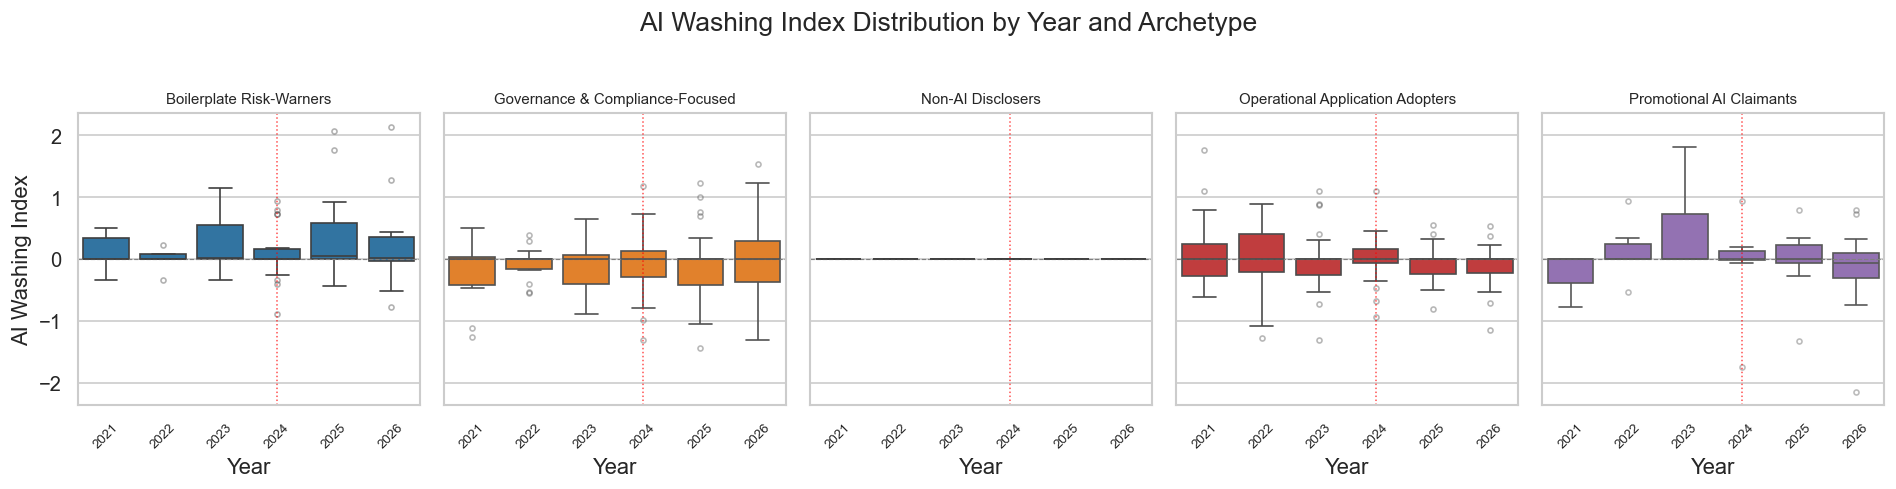

In [39]:
fig, axes = plt.subplots(1, n, figsize=(n * 3.2, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, label in zip(axes, labels_sorted):
    sub = df[df['label'] == label]
    sns.boxplot(data=sub, x='year', y='ai_washing_index',
                color=palette[label], ax=ax,
                flierprops=dict(markersize=3, alpha=0.4))
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.axvline(
        list(sorted(sub['year'].unique())).index(2024) if 2024 in sub['year'].values else -1,
        color='red', linewidth=0.9, linestyle=':', alpha=0.7
    )
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

axes[0].set_ylabel('AI Washing Index')
fig.suptitle('AI Washing Index Distribution by Year and Archetype', y=1.02)
plt.tight_layout()
plt.savefig('../reports/ai_washing_boxplot_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Pre / post SEC guidance shift per cluster

Pre (0) vs Post (1) SEC guidance — mean AI washing index and shift:
                                  ai_washing_index_0  ai_washing_index_1  washing_shift
label                                                                                  
Promotional AI Claimants                       0.200              -0.069         -0.269
Operational Application Adopters               0.008              -0.054         -0.062
Non-AI Disclosers                              0.000               0.000          0.000
Governance & Compliance-Focused               -0.134              -0.068          0.066
Boilerplate Risk-Warners                       0.129               0.212          0.083


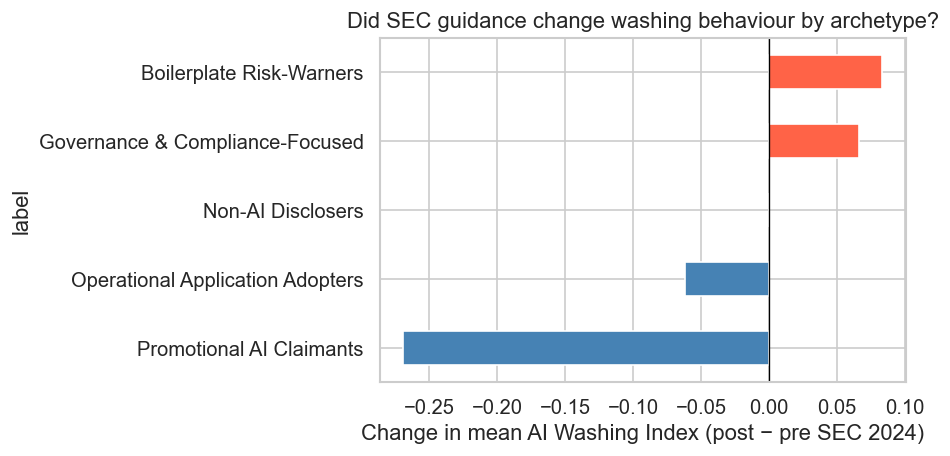

In [40]:
shift = (
    df.groupby(['label', 'post_sec_2024'])[['ai_washing_index', 'hype_score', 'substance_score']]
    .mean()
    .unstack('post_sec_2024')
    .round(3)
)
shift.columns = ['_'.join(str(c) for c in col) for col in shift.columns]
shift['washing_shift'] = shift.get('ai_washing_index_1', 0) - shift.get('ai_washing_index_0', 0)
print('Pre (0) vs Post (1) SEC guidance — mean AI washing index and shift:')
print(shift[['ai_washing_index_0', 'ai_washing_index_1', 'washing_shift']].sort_values('washing_shift').to_string())

fig, ax = plt.subplots(figsize=(8, 4))
shift['washing_shift'].sort_values().plot(kind='barh', ax=ax, color=[
    'tomato' if v > 0 else 'steelblue' for v in shift['washing_shift'].sort_values()
])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in mean AI Washing Index (post − pre SEC 2024)')
ax.set_title('Did SEC guidance change washing behaviour by archetype?')
plt.tight_layout()
plt.savefig('../reports/ai_washing_sec_shift.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Firm-level trajectories — spaghetti within each cluster

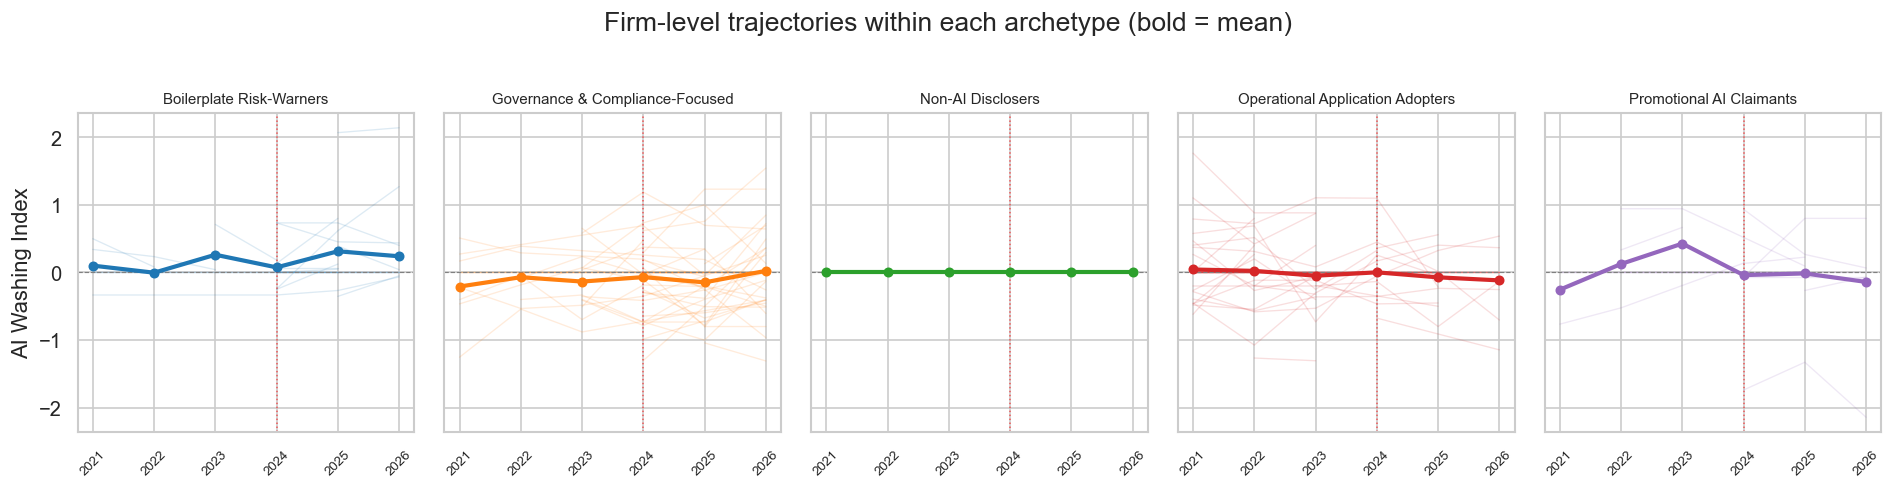

In [41]:
fig, axes = plt.subplots(1, n, figsize=(n * 3.2, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, label in zip(axes, labels_sorted):
    sub = df[df['label'] == label].sort_values('year')
    grp_mean = sub.groupby('year')['ai_washing_index'].mean()

    for ticker, firm_df in sub.groupby('ticker'):
        firm_df = firm_df.sort_values('year')
        if len(firm_df) > 1:
            ax.plot(firm_df['year'], firm_df['ai_washing_index'],
                    color=palette[label], alpha=0.15, linewidth=0.8)

    ax.plot(grp_mean.index, grp_mean.values,
            color=palette[label], linewidth=2.5, zorder=5, marker='o', markersize=5)

    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.axvline(2024, color='red', linewidth=0.9, linestyle=':', alpha=0.6)
    ax.set_title(label, fontsize=9)
    ax.set_xticks(sorted(sub['year'].unique()))
    ax.tick_params(axis='x', rotation=45, labelsize=8)

axes[0].set_ylabel('AI Washing Index')
fig.suptitle('Firm-level trajectories within each archetype (bold = mean)', y=1.02)
plt.tight_layout()
plt.savefig('../reports/ai_washing_spaghetti_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
